# Imports

In [13]:
import abtem
import numpy as np
from ase import Atoms
import seaborn as sns
from pathlib import Path
from ase.io import read, write
from ase.build import molecule
from ase.visualize import view
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
from ase.cluster import wulff_construction
abtem.config.set({"precision": "float32"})
from pt_cluster.functions import (place_ontop, Zoneaxis3, Zoneaxis4, stable_solution)

In [14]:
data = Path("/zhome/f1/0/167759/10387/data")
data.mkdir(parents=True, exist_ok=True)

# Creating Model

In [15]:
# Fractional surface energies for Pt facets (100, 110, 111) given in [eV/Å^2]. http://crystalium.materialsvirtuallab.org/
surfaces = [(1, 0, 0), (1, 1, 0), (1, 1, 1), (3,3,2), (3,2,2), (2,2,1), (3,3,1), (2,1,1), (3,2,1), (3,1,1), (3,1,0), (2,1,0), (3,2,0)] # 
esurf = [0.116, 0.117, 0.093, 0.097, 0.099, 0.100, 0.106, 0.110, 0.110, 0.112, 0.117, 0.118, 0.118] # 

# Lattice constant for FCC
lc = 3.9236 # lattice constant 392.36 pm in Å. https://en.wikipedia.org/wiki/Platinum

# N atoms in the cluster, 1727 = 3,541nm, 4045 = 48.16Å, 14001 = 74,34Å
size = 4045

In [16]:
# Creating Pt cluster using ASE python package "wulff_construction"
Pt = wulff_construction('Pt', surfaces, esurf,
                           size = size, structure = 'fcc',
                           rounding='closest', latticeconstant=lc)

buffer = Pt.get_diameter(method = "shape")
print(f' diameter = {buffer}', f'atoms = {len(Pt)}')

 diameter = 48.15620629885753 atoms = 4045


In [18]:
atom = Pt.copy()
atom = stable_solution(atom)
theta, phi = Zoneaxis4((1,1,0))

atom.rotate(theta, (1, 0, 0), center=(0, 0, 0), rotate_cell=False)
atom.rotate(phi, (0, 1, 0), center=(0, 0, 0), rotate_cell=False)

atom.center(buffer)

view(atom, viewer="x3d")

In [20]:
# Load the model
atom = read(data/ f"models/Pt5nm_cov.traj")

In [21]:
flip = atom.copy()

flip.rotate(180, (1, 0, 0), center=(0, 0, 0), rotate_cell=True)

In [22]:
# Plot settings
font = {'fontname':'Arial'}
font_size = 14
title_size = 18
tick_font = {'labelfontfamily':'Arial'}
tick_size = 14

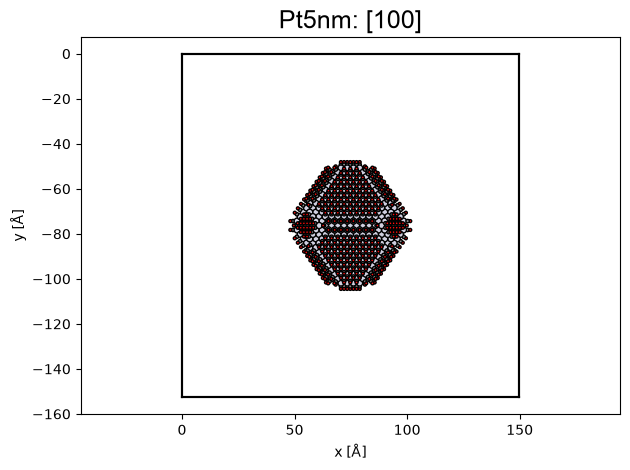

In [23]:
fig, ax = plt.subplots()
abtem.show_atoms(flip, ax=ax, scale=1)
ax.set_title(f"Pt5nm: [100]",fontsize=title_size, **font)
plt.tight_layout()

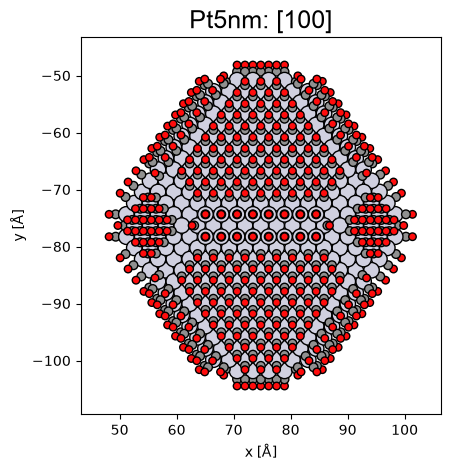

In [24]:
fig, ax = plt.subplots()

abtem.show_atoms(flip, ax=ax, scale=1)

pos = flip.positions

pad = 5.0

xmin = pos[:, 0].min() - pad
xmax = pos[:, 0].max() + pad
ymin = pos[:, 1].min() - pad
ymax = pos[:, 1].max() + pad

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal", adjustable="box")

ax.set_title(f"Pt5nm: [100]", fontsize=title_size, **font)
plt.tight_layout()

# Image settings

In [10]:
# Abberation from Visions TEM "Prime" by Idan Biran.
energy = 300e3 # Abberations are based of 300keV
C10 = 55         # Defocus            # 55 Å
C12 = 39.53      # A1, astigmatisme   # 3.953 nm
C23 = 204.7      # A2, trefoil        # 20.47 nm
C21 = 147.7      # B2, coma           # 14.77 nm
C30 = -14.72e4   # C3, Cs (spherical) # -14.72 µm
C34 = 1272       # A3, quadrafoil     # 127.2 nm
C32 = 695.6      # S3, astigmatisme2  # 69.56 nm
C45 = 5.28e4     # A4, pentafoil      # 5.28 µm
C43 = 3.033e4    # D4, trefoil2       # 3.022 µm
C41 = 9.802e4    # B4, coma2          # 9.892 µm
C50 = 7.606e7    # C5, C5 (spherical) # 7.606 mm
C56 = 202e4      # A4, hexafoil       # 202 µm

In [11]:
# Angle correction (phi) for abberations for the new TEM.
phi12 = 47.5*np.pi/180     # A1, astigmatisme   # 47.5°
phi23 = 81.5*np.pi/180     # A2, trefoil        # 81.5°
phi21 = 13.0*np.pi/180     # B2, coma           # 13.0°
# phi30 {C3, Cs (spherical)} has no phi dependency.
phi34 = -28.4*np.pi/180    # A3, quadrafoil     # -28.4°
phi32 = 41.7*np.pi/180     # S3, astigmatisme2  # 41.7°
phi45 = -109.7*np.pi/180   # A4, pentafoil      # -109.7°
phi43 = 131.8*np.pi/180    # D4, trefoil2       # 131.8°
phi41 = -63.0*np.pi/180    # B4, coma2          # -63.0°
# phi50 { C5, C5 (spherical)} has no phi dependency.
phi56 = -0.7*np.pi/180     # A4, hexafoil       # -0.7°

## Imaging

In [ ]:
# Load the data from the zarr file.
atom_ewave = abtem.from_zarr(data / "exit_waves/atom.zarr")

In [ ]:
# Focal settings from Visions TEM "Prime" by Idan Biran.
Cc = 1.6e-3 * 1e10 # Chromatic aberration in Å.
energy_spread = 0.105 # Use the best focal spread in eV
focal_spread = np.abs(Cc) * energy_spread / energy  # Focal spread for Titan.
focal_spread = focal_spread*np.sqrt(2) # Correction for temporal evelope in abTEM.

# Inserting abberation for PRIME.
# Spherical aberration_coefficients based of defocus = C10 = 0
# The C10 is defined without a vacuum, thus "C10 - buffer"
aberration_coefficients = {"C10": C10 - buffer, "C30": C30, "C50": C50}

# Creating the contrast transfer function 
ctf = abtem.CTF(aberration_coefficients=aberration_coefficients, energy=energy, focal_spread=focal_spread)


In [ ]:
prime = Pt.copy()
prime.rotate(180, (1, 0, 0), center=(0, 0, 0), rotate_cell=True)

In [ ]:
im = atom_ewave.apply_ctf(ctf).intensity()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

abtem.show_atoms(prime, ax = axes[0,0], scale = 1)
abtem.show_atoms(flip, ax = axes[0,0], scale = 1)
im.show(ax = axes[0,2], common_color_scale=True, cbar=True, cmap = "Greys_r")

axes[0,0].set_title(f"Pt5nm [110]",fontsize=title_size, **font)
axes[0,1].set_title(f"+Full coverage [110]",fontsize=title_size, **font)
axes[0,2].set_title(f"TEM Image: 55Å",fontsize=title_size, **font)

fig.tight_layout();
plt.savefig("step_for_step_im.svg", bbox_inches='tight')
plt.show()

# Quscope